# Data Memo — Working Notes

## 1. Purpose

This project examines whether the internal behavior of U.S. inflation (CPI and PCE) changes after major shocks: COVID-19, domestic tariff policy, and geopolitical conflict. It also examines sub-categories (food, energy, gasoline, electricity) to see how their behavior differs in response to each event.

## 2. Data Source
### Series

All series are monthly and seasonally adjusted.

| Group | Series | FRED ID | Source | Units |
|---|---|---|---|---|
| Headline | CPI-U: All Items in U.S. City Average | `CPIAUCSL` | BLS | Index 1982–84 = 100 |
| Headline | CPI-U: All Items Less Food and Energy (core) | `CPILFESL` | BLS | Index 1982–84 = 100 |
| Headline | Personal Consumption Expenditures: Chain-type Price Index | `PCEPI` | BEA | Index 2017 = 100 |
| Food | CPI-U: Food | `CPIUFDSL` | BLS | Index 1982–84 = 100 |
| Energy | CPI-U: Energy | `CPIENGSL` | BLS | Index 1982–84 = 100 |
| Gasoline | CPI-U: Gasoline (All Types) | `CUSR0000SETB01` | BLS | Index 1982–84 = 100 |
| Electricity | CPI-U: Electricity | `CUSR0000SEHF01` | BLS | Index 1982–84 = 100 |

### Series descriptions

- **CPI-U (`CPIAUCSL`):** tracks the average change over time in prices paid by urban consumers for a market basket of consumer goods and services.
- **PCE price index (`PCEPI`):** measures prices paid for goods and services by consumers across the entire U.S. economy. Its coverage is broader than CPI's, and it is the Federal Reserve's preferred inflation measure.
- **Core CPI (`CPILFESL`):** CPI-U excluding the volatile food and energy components.

### References

FRED's suggested citation format; the date is the date the data were retrieved.

U.S. Bureau of Economic Analysis, Personal Consumption Expenditures: Chain-type Price Index [PCEPI], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/PCEPI, October 2, 2026.

U.S. Bureau of Labor Statistics, Consumer Price Index for All Urban Consumers: All Items in U.S. City Average [CPIAUCSL], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/CPIAUCSL, October 2, 2026.

U.S. Bureau of Labor Statistics, Consumer Price Index for All Urban Consumers: All Items Less Food and Energy in U.S. City Average [CPILFESL], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/CPILFESL, October 2, 2026.

U.S. Bureau of Labor Statistics, Consumer Price Index for All Urban Consumers: Electricity in U.S. City Average [CUSR0000SEHF01], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/CUSR0000SEHF01, October 2, 2026.

U.S. Bureau of Labor Statistics, Consumer Price Index for All Urban Consumers: Energy in U.S. City Average [CPIENGSL], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/CPIENGSL, October 2, 2026.

U.S. Bureau of Labor Statistics, Consumer Price Index for All Urban Consumers: Food in U.S. City Average [CPIUFDSL], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/CPIUFDSL, October 2, 2026.

U.S. Bureau of Labor Statistics, Consumer Price Index for All Urban Consumers: Gasoline (All Types) in U.S. City Average [CUSR0000SETB01], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/CUSR0000SETB01, October 2, 2026.

## Data pull (FRED)

In [1]:
"""
Data memo: pull CPI / PCE price indexes from FRED, transform them, and document them.

Inputs : FRED, via pandas_datareader (no API key required). The pull runs only when
         data/raw/fred_prices_raw.csv is missing or REFRESH_DATA = True; otherwise the
         saved raw file is reused so results reproduce exactly.
Outputs: data/raw/fred_prices_raw.csv            raw index levels, exactly as downloaded
         data/clean/inflation_annualized.csv     annualized monthly inflation, main sample
         output/fig_headline_price_levels.png    raw headline index levels
         output/fig_subcategory_price_levels.png raw sub-category index levels
         output/fig_headline_inflation.png       annualized monthly inflation, headline
         output/table_summary_headline.csv       summary stats + ADF/KPSS, headline, by subsample
         output/table_summary_subcategories.csv  same, CPI sub-categories
"""
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Project folders. This notebook lives in code/, so the project root is one level up;
# the check also lets it run from the project root itself.
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
RAW_DIR = ROOT / "data" / "raw"
CLEAN_DIR = ROOT / "data" / "clean"
OUTPUT_DIR = ROOT / "output"
for folder in (RAW_DIR, CLEAN_DIR, OUTPUT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

# FRED ID -> (label, group). The group drives the per-category DataFrames and plot panels.
# All series are monthly and seasonally adjusted.
SERIES = {
    "CPIAUCSL":       ("CPI: All items",                         "Headline"),
    "CPILFESL":       ("CPI: All items less food & energy (core)", "Headline"),
    "PCEPI":          ("PCE chain-type price index",             "Headline"),
    "CPIUFDSL":       ("CPI: Food",                              "Food"),
    "CPIENGSL":       ("CPI: Energy",                            "Energy"),
    "CUSR0000SETB01": ("CPI: Gasoline (all types)",              "Gasoline"),
    "CUSR0000SEHF01": ("CPI: Electricity",                       "Electricity"),
}
LABELS = {k: v[0] for k, v in SERIES.items()}
GROUPS = {k: v[1] for k, v in SERIES.items()}

# Break dates marked on the plots (same as the Sample Description table).
EVENTS = {
    "COVID-19":      "2020-03-01",
    "2025 tariffs":  "2025-04-01",
    "Iran conflict": "2025-06-01",
}

# False = reuse the saved raw file (reproducible). True = re-download FRED's latest vintage,
# which overwrites data/raw and can change every number in the memo.
REFRESH_DATA = False

# Set to e.g. "2010-01-01" to zoom the plots on recent shocks; None plots full history.
PLOT_START = None

In [2]:
import re

import pandas_datareader.data as web


def fetch_fred(series_ids, start="1947-01-01"):
    """Download FRED series as one wide DataFrame indexed by month.

    Uses pandas_datareader's FRED reader, which needs no API key. Values are
    returned exactly as published (index levels, no transformation).
    `start` must be set explicitly: the reader defaults to the last 5 years.
    """
    df = web.DataReader(series_ids, "fred", start=start)
    df.index.name = "date"
    return df


raw_path = RAW_DIR / "fred_prices_raw.csv"
readme_path = RAW_DIR / "fred_prices_raw_README.txt"

if REFRESH_DATA or not raw_path.exists():
    prices_raw = fetch_fred(list(SERIES))
    RETRIEVED = date.today().isoformat()  # cite this as the retrieval date in the memo
    FRESH_PULL = True
else:
    # Reuse the saved raw file, keeping only the series in SERIES; the retrieval date
    # is read from its README.
    prices_raw = pd.read_csv(raw_path, parse_dates=["date"], index_col="date")[list(SERIES)]
    RETRIEVED = re.search(r"Retrieved: (\S+)", readme_path.read_text()).group(1)
    FRESH_PULL = False

# One DataFrame per category (e.g. dfs["Food"]). Series start in different years,
# so drop only the months where no series in that group has data yet.
dfs = {
    g: prices_raw[[k for k in SERIES if GROUPS[k] == g]].dropna(how="all")
    for g in dict.fromkeys(GROUPS.values())
}

print(f"{'Downloaded' if FRESH_PULL else 'Loaded saved pull from'} {RETRIEVED}: {prices_raw.shape[1]} series, "
      f"{prices_raw.index.min():%Y-%m} to {prices_raw.index.max():%Y-%m}")
print("Groups:", {g: list(d.columns) for g, d in dfs.items()})

Downloaded 2026-10-02: 7 series, 1947-01 to 2026-08
Groups: {'Headline': ['CPIAUCSL', 'CPILFESL', 'PCEPI'], 'Food': ['CPIUFDSL'], 'Energy': ['CPIENGSL'], 'Gasoline': ['CUSR0000SETB01'], 'Electricity': ['CUSR0000SEHF01']}


In [3]:
# Save the raw pull exactly as downloaded: full history, index levels, no transformation.
# Only written on a fresh pull (REFRESH_DATA = True or no saved file), so re-running the
# notebook never silently replaces the data behind the memo with a newer FRED vintage.
if FRESH_PULL:
    prices_raw.to_csv(raw_path)

    # Record when and how the file was retrieved, since FRED data change over time.
    readme_path.write_text(
        f"Source: FRED, Federal Reserve Bank of St. Louis, via pandas_datareader\n"
        f"Retrieved: {RETRIEVED}\n"
        f"Series (monthly, seasonally adjusted index levels): {', '.join(SERIES)}\n"
        f"Note: October 2025 is missing for every BLS CPI series except gasoline "
        f"(CUSR0000SETB01) (not collected during the federal government shutdown).\n"
    )
    print(f"Saved {raw_path} ({prices_raw.shape[0]} rows x {prices_raw.shape[1]} series)")
else:
    print(f"Using saved {raw_path.name}; set REFRESH_DATA = True to re-download.")


Saved C:\Users\Alex\OneDrive - The University of Texas at El Paso\Documents\ECON 5371 Forecasting\alexg171.github.io\data\raw\fred_prices_raw.csv (956 rows x 7 series)


In [4]:
# Coverage table: first/last month and observation count per series.
# The common start date (the latest "Start") bounds any sample that uses all series together.
coverage = pd.DataFrame(
    {
        "Series": [LABELS[k] for k in prices_raw],
        "Group": [GROUPS[k] for k in prices_raw],
        "Start": [prices_raw[k].first_valid_index().strftime("%Y-%m") for k in prices_raw],
        "End": [prices_raw[k].last_valid_index().strftime("%Y-%m") for k in prices_raw],
        "Obs": prices_raw.notna().sum().values,
    },
    index=pd.Index(prices_raw.columns, name="FRED ID"),
)
coverage

,Series,Group,Start,End,Obs
FRED ID,,,,,
CPIAUCSL,CPI: All items,Headline,1947-01,2026-08,955
CPILFESL,CPI: All items less food & energy (core),Headline,1957-01,2026-08,835
PCEPI,PCE chain-type price index,Headline,1959-01,2026-08,812
CPIUFDSL,CPI: Food,Food,1947-01,2026-08,955
CPIENGSL,CPI: Energy,Energy,1957-01,2026-08,835
CUSR0000SETB01,CPI: Gasoline (all types),Gasoline,1967-01,2026-08,716
CUSR0000SEHF01,CPI: Electricity,Electricity,1952-01,2026-08,895


## Raw series plots

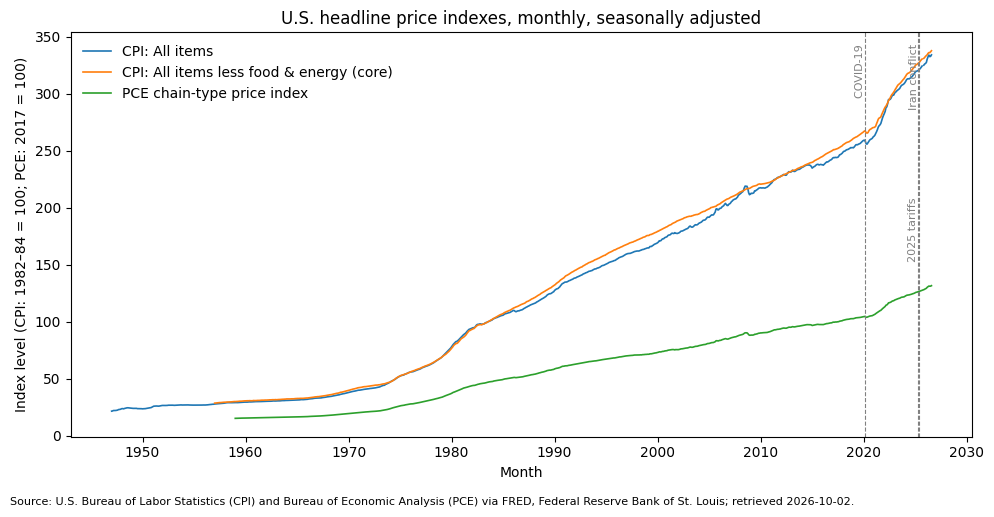

In [5]:
def mark_events(ax, events=EVENTS, label=True):
    """Draw a dashed vertical line at each event date on `ax`, optionally labeled."""
    for i, (name, d) in enumerate(events.items()):
        ax.axvline(pd.Timestamp(d), color="gray", ls="--", lw=0.8)
        if label:
            # x in data units, y in axes units; alternate heights so close dates don't overlap
            y = 0.98 if i % 2 == 0 else 0.60
            ax.text(pd.Timestamp(d), y, f"{name} ", transform=ax.get_xaxis_transform(),
                    rotation=90, va="top", ha="right", fontsize=8, color="gray")


def save_fig(fig, filename):
    """Save `fig` to output/ as a 300-dpi PNG, keeping text placed outside the axes."""
    fig.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")


# Raw (untransformed) headline price levels.
# PCE uses a different base year than CPI, so the y-label states both bases.
headline = dfs["Headline"].loc[PLOT_START:]

fig, ax = plt.subplots(figsize=(10, 5))
for k in headline:
    ax.plot(headline.index, headline[k], lw=1.2, label=LABELS[k])
mark_events(ax)
ax.set(title="U.S. headline price indexes, monthly, seasonally adjusted",
       xlabel="Month", ylabel="Index level (CPI: 1982–84 = 100; PCE: 2017 = 100)")
ax.legend(loc="upper left", frameon=False)
fig.text(0.01, -0.02,
         f"Source: U.S. Bureau of Labor Statistics (CPI) and Bureau of Economic Analysis (PCE) "
         f"via FRED, Federal Reserve Bank of St. Louis; retrieved {RETRIEVED}.",
         fontsize=8, ha="left")
fig.tight_layout()
save_fig(fig, "fig_headline_price_levels.png")
plt.show()

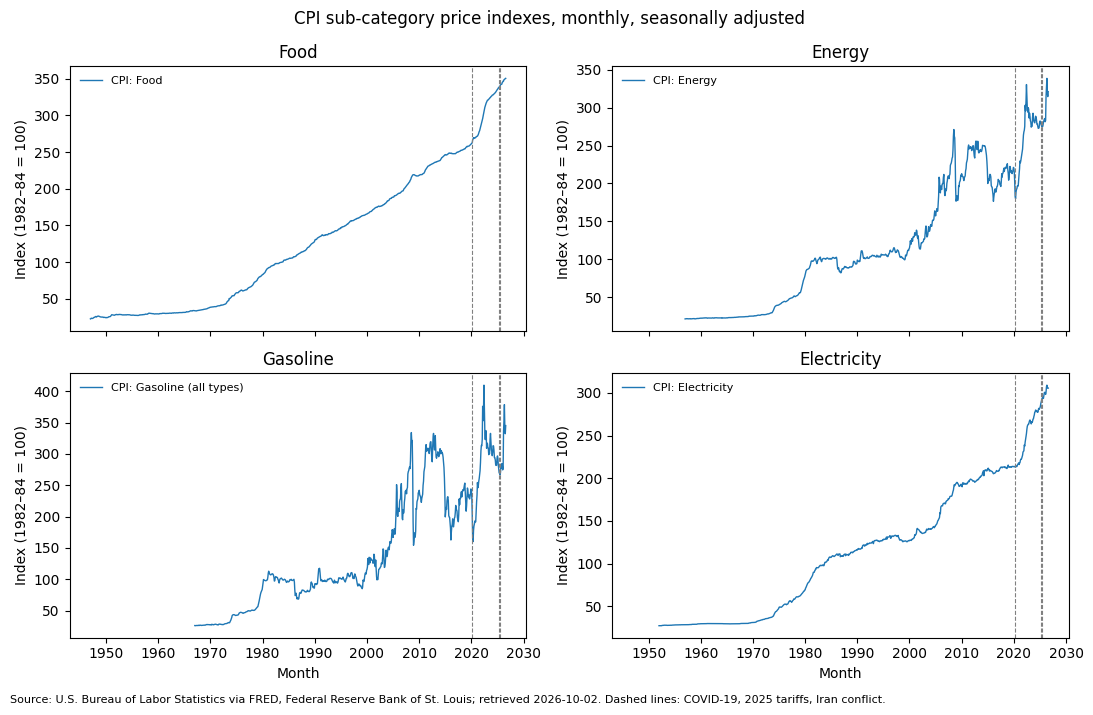

In [6]:
# Raw index levels by sub-category, one panel per group.
# All four groups are BLS CPI indexes on the same 1982-84 = 100 base, so levels are comparable
# within a panel. Dashed lines mark the EVENTS dates (unlabeled here to keep panels readable).
categories = [g for g in dfs if g != "Headline"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, g in zip(axes.flat, categories):
    sub = dfs[g].loc[PLOT_START:]
    for k in sub:
        ax.plot(sub.index, sub[k], lw=1, label=LABELS[k])
    mark_events(ax, label=False)
    ax.set_title(g)
    ax.set_ylabel("Index (1982–84 = 100)")
    ax.legend(fontsize=8, frameon=False, loc="upper left")
for ax in axes[-1]:
    ax.set_xlabel("Month")

fig.suptitle("CPI sub-category price indexes, monthly, seasonally adjusted")
fig.text(0.01, -0.01,
         f"Source: U.S. Bureau of Labor Statistics via FRED, Federal Reserve Bank of St. Louis; "
         f"retrieved {RETRIEVED}. Dashed lines: {', '.join(EVENTS)}.",
         fontsize=8, ha="left")
fig.tight_layout()
save_fig(fig, "fig_subcategory_price_levels.png")
plt.show()

## 3. Sample Description

### Frequency

**Monthly.** All series are published monthly. Aggregating to quarterly would cut the number of observations and leave out important data points, especially in the short windows after each shock.

### Sample period

**January 1985 – August 2026** (main sample). All series are available from January 1967 onward, but the main sample starts in 1985 to exclude the volatility of the 1970s and begin from a stable, low-inflation baseline. The full 1967 sample is kept for robustness checks.

### Break dates and subsamples

| Event | Break date |
|---|---|
| COVID-19 | March 2020 |
| 2025 tariffs | April 2025 |
| Iran conflict | February 2026 |

### Transformations

Inflation is computed as **π<sub>t</sub> = 1200 · (ln P<sub>t</sub> − ln P<sub>t−1</sub>)**, in four steps:

1. **Seasonal adjustment.** Seasonally adjusted series are used to focus on each series' underlying behavior rather than its seasonal pattern.
2. **Log.** Taking the natural log turns differences into percent changes.
3. **First difference (1 month).** Differencing removes the trend in the price level, turning it into a monthly inflation rate.
4. **Scale by 1200.** Multiplying by 1200 (100 × 12 months) expresses inflation as an annualized percentage rate.

**Stationarity check.** ADF and KPSS tests on π indicate the series is now stationary, so no second difference is needed. Six of seven series pass both tests.

## Transformations

Each series is shown at every step of the transformation pipeline, over the main sample (1985-01 to 2026-08):

1. **Seasonally adjusted level:** the raw index, trending upward.
2. **Log:** same trend; equal *percent* changes now look equal in size.
3. **1-month difference:** the trend is gone; the series fluctuates around a stable mean (monthly inflation, in decimals).
4. **× 1200:** identical shape to step 3; only the units change, to annualized percent.

All candidate transformations (12-month difference, year-over-year, monthly %, second difference) are still computed in `tx` for comparison, but only the chosen pipeline is plotted.

In [7]:
import numpy as np

# Main estimation sample: start after the 1970s-early 80s high-inflation regime;
# end date fixed so results stay reproducible as FRED adds/revises data.
# (1967-01, the common start of all series, is kept for robustness checks.)
SAMPLE_START, SAMPLE_END = "1985-01-01", "2026-08-01"

log_prices = np.log(prices_raw)

# Every candidate transformation, for all series. Differences are computed on the full
# history *before* trimming, so Jan 1985 still has a value (it uses Dec 1984 / Jan 1984).
#   d1   = ln P_t - ln P_{t-1}           (1-month growth, decimal)
#   d12  = ln P_t - ln P_{t-12}          (12-month growth, decimal)
#   d2   = change in ann from last month (second difference of log level, x1200)
#   mom  = 100 * d1                      (% per month)
#   ann  = 1200 * d1                     (% per year, annualized monthly inflation)
#   yoy  = 100 * d12                     (% vs. same month last year)
_full = {
    "level": prices_raw,
    "log":   log_prices,
    "d1":    log_prices.diff(1),
    "d12":   log_prices.diff(12),
    "d2":    1200 * log_prices.diff(1).diff(1),
    "mom":   100 * log_prices.diff(1),
    "ann":   1200 * log_prices.diff(1),
    "yoy":   100 * log_prices.diff(12),
}
tx = {k: df.loc[SAMPLE_START:SAMPLE_END] for k, df in _full.items()}  # e.g. tx["ann"]["CPIAUCSL"]

# Panel title and y-axis units for each transformation (dict order = plot order)
TX_INFO = {
    "level": ("Level (raw)",                          "Index"),
    "log":   ("Log level",                            "ln(index)"),
    "d1":    ("1-month log difference",               "Δ ln P (decimal)"),
    "d12":   ("12-month log difference",              "Δ₁₂ ln P (decimal)"),
    "d2":    ("Second difference: Δ(annualized π)",   "Percentage points"),
    "mom":   ("Monthly inflation (×100)",             "% per month"),
    "ann":   ("Annualized monthly inflation (×1200)", "% per year"),
    "yoy":   ("Year-over-year inflation (×100)",      "%"),
}

print(f"Sample {SAMPLE_START[:7]} to {SAMPLE_END[:7]}: {len(tx['ann'])} months; "
      f"{len(TX_INFO)} transformations x {prices_raw.shape[1]} series")

Sample 1985-01 to 2026-08: 500 months; 8 transformations x 7 series


In [8]:
# Save the clean estimation dataset: annualized monthly inflation (pi = 1200 * dln P)
# for every series over the main sample. Columns are FRED IDs.
# October-November 2025 are blank for the CPI series because October 2025 CPI was never
# published; how to fill that gap is still to be decided.
clean_path = CLEAN_DIR / "inflation_annualized.csv"
tx["ann"].to_csv(clean_path, float_format="%.6f")
print(f"Saved {clean_path} ({tx['ann'].shape[0]} months x {tx['ann'].shape[1]} series, "
      f"{SAMPLE_START[:7]} to {SAMPLE_END[:7]})")

Saved C:\Users\Alex\OneDrive - The University of Texas at El Paso\Documents\ECON 5371 Forecasting\alexg171.github.io\data\clean\inflation_annualized.csv (500 months x 7 series, 1985-01 to 2026-08)


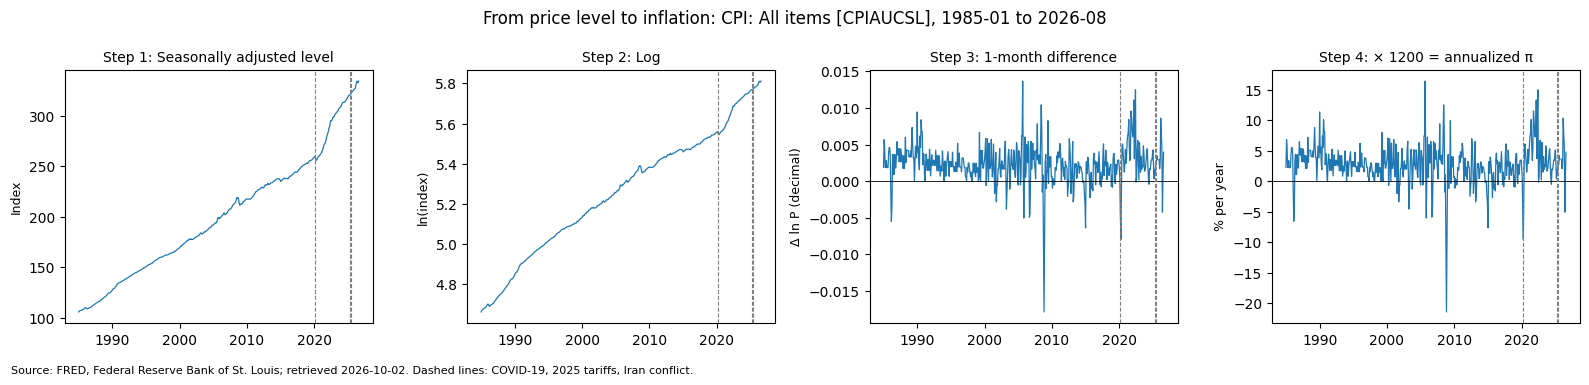

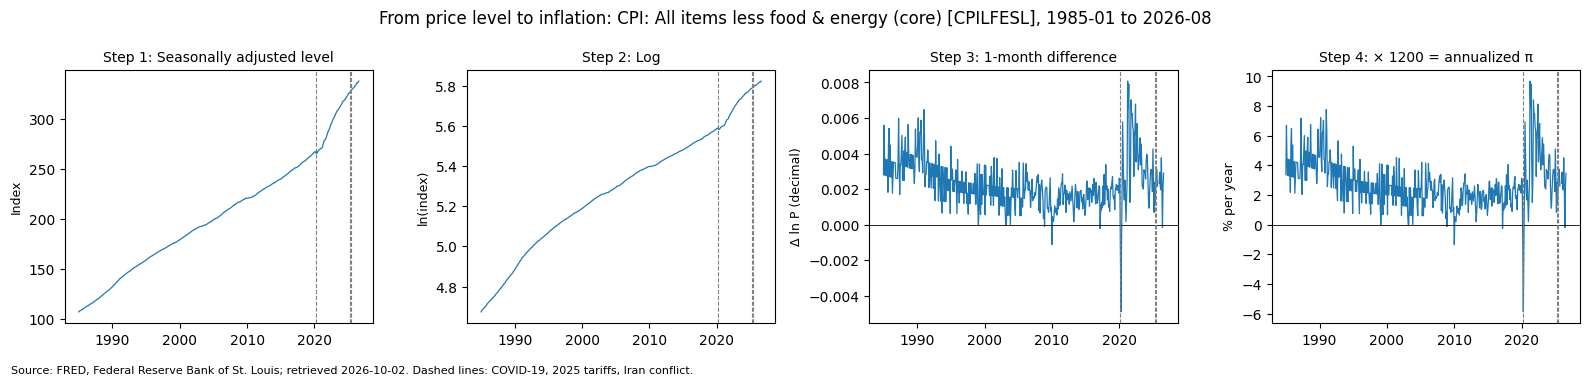

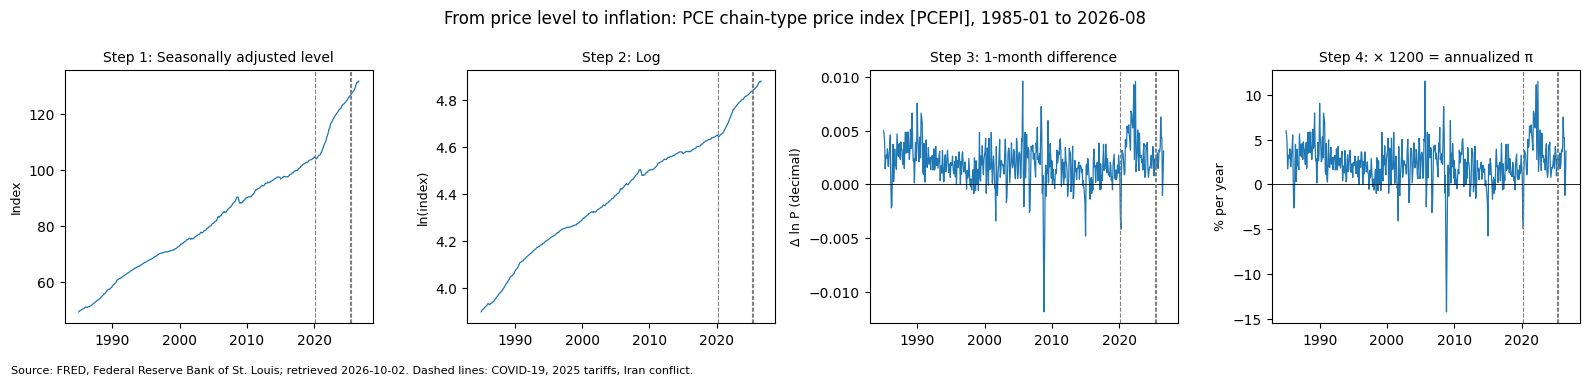

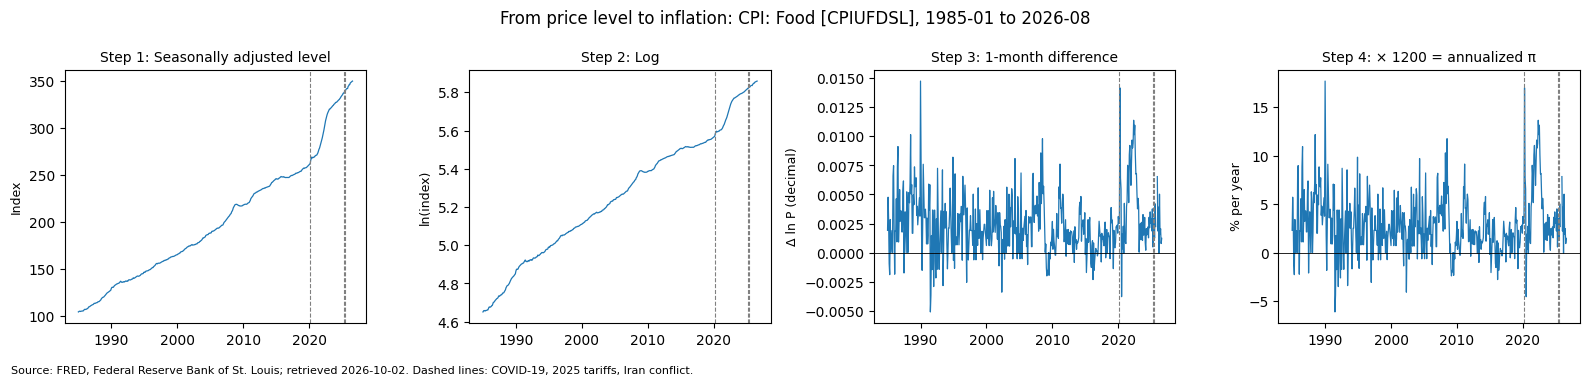

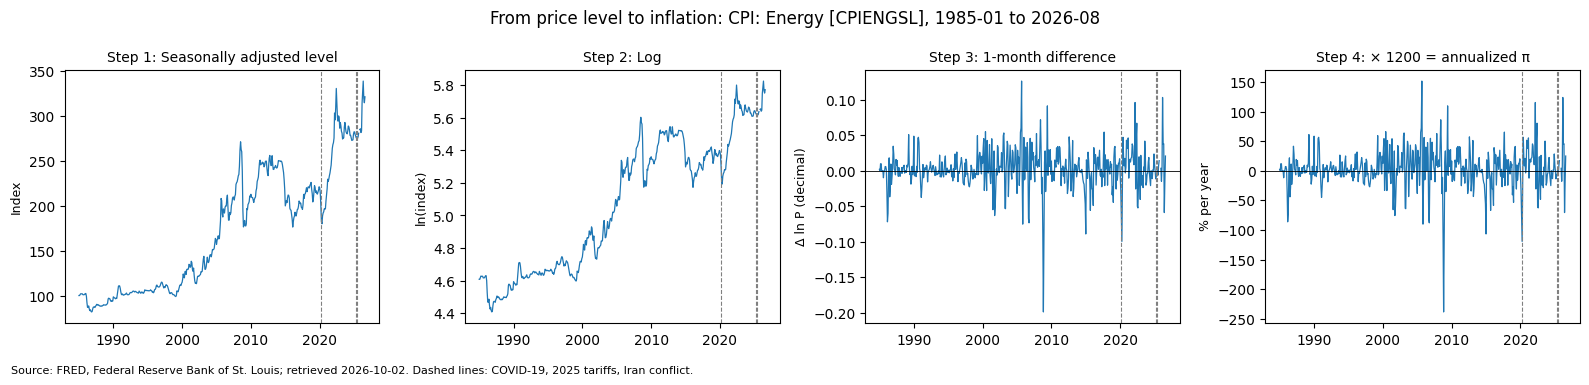

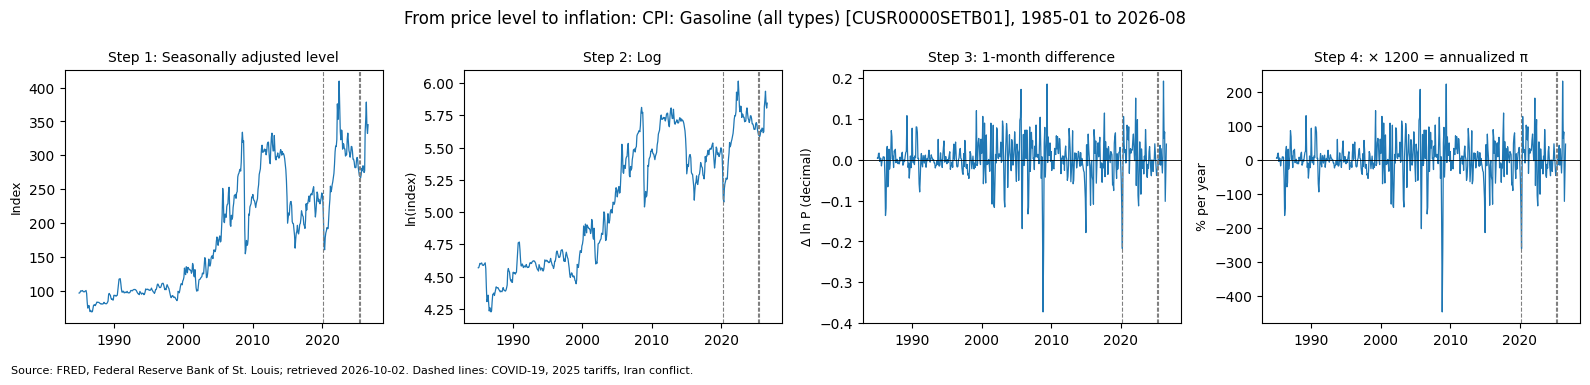

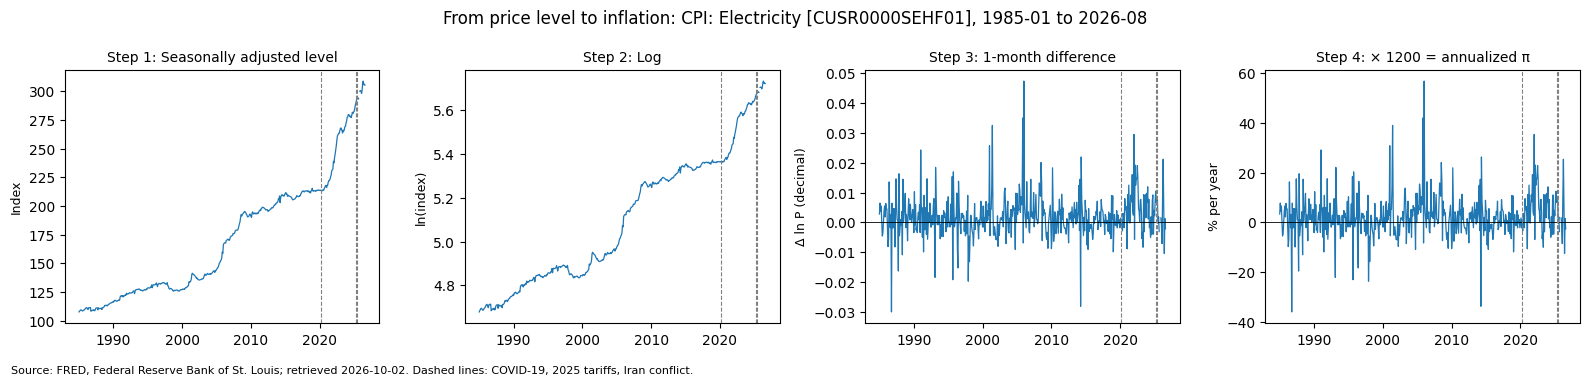

In [9]:
import matplotlib.dates as mdates

# The chosen transformation pipeline, one panel per step (keys index into `tx`).
# Steps 3 and 4 have the same shape; step 4 only rescales into annualized percent.
STEPS = {
    "level": ("Step 1: Seasonally adjusted level", "Index"),
    "log":   ("Step 2: Log",                       "ln(index)"),
    "d1":    ("Step 3: 1-month difference",        "Δ ln P (decimal)"),
    "ann":   ("Step 4: × 1200 = annualized π",     "% per year"),
}


def plot_steps(series_id):
    """Plot the four transformation steps for one series, left to right."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharex=True)
    for ax, (key, (title, units)) in zip(axes, STEPS.items()):
        s = tx[key][series_id]
        ax.plot(s.index, s, lw=0.9)
        if key in ("d1", "ann"):
            ax.axhline(0, color="black", lw=0.6)  # differenced series fluctuate around zero
        mark_events(ax, label=False)
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(units, fontsize=9)
        ax.xaxis.set_major_locator(mdates.YearLocator(10))  # one tick per decade keeps labels readable
    fig.suptitle(f"From price level to inflation: {LABELS[series_id]} [{series_id}], "
                 f"{SAMPLE_START[:7]} to {SAMPLE_END[:7]}")
    fig.text(0.01, -0.03,
             f"Source: FRED, Federal Reserve Bank of St. Louis; retrieved {RETRIEVED}. "
             f"Dashed lines: {', '.join(EVENTS)}.",
             fontsize=8, ha="left")
    fig.tight_layout()
    plt.show()


# One row per series, headline first.
for sid in SERIES:
    plot_steps(sid)

## 4. Data Documentation: Summary Statistics

Summary statistics for **annualized monthly inflation** (π = 1200·Δln P) for the three headline measures and the CPI sub-categories, over the full sample and split at the COVID break (March 2020).

**Reading the stationarity tests:**
- **ADF:** null hypothesis = unit root. A *small* p-value (< 0.05) means stationary.
- **KPSS:** null hypothesis = stationary. A *large* p-value (> 0.05) means stationary.
- The two tests agree on stationarity when ADF p is small **and** KPSS p is large.

**Reading the other columns:**
- **Mean vs. Median:** RMSE rewards forecasting the mean, MAE the median. A large gap (and nonzero skewness) means the two metrics can rank models differently.
- **JB p (Jarque–Bera):** null = normal. A *small* p-value means fat tails or skew, so intervals that assume normal errors may have the wrong coverage.
- **LB(12) p (Ljung–Box, 12 lags):** null = white noise. A *small* p-value means past inflation helps predict future inflation.
- **Naive RMSE:** one-step error of the random-walk forecast (next month = this month). This is the benchmark the models in later sections must beat.

In [10]:
import warnings

from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss

# Headline measures (CPI, core CPI, PCE) and CPI sub-categories get separate tables.
HEADLINE = [k for k in SERIES if GROUPS[k] == "Headline"]
SUBCATS = [k for k in SERIES if GROUPS[k] != "Headline"]

# Full sample plus the split at the COVID break (March 2020 is the first post-break month).
COVID_BREAK = "2020-03-01"
PRE_END = "2020-02-01"
SUBSAMPLES = {
    "Full":       (SAMPLE_START, SAMPLE_END),
    "Pre-COVID":  (SAMPLE_START, PRE_END),
    "Post-COVID": (COVID_BREAK, SAMPLE_END),
}


def describe_inflation(s):
    """Return summary statistics and ADF/KPSS p-values for one inflation series.

    AR(1) is the lag-1 autocorrelation, a first read on persistence ("memory").
    Mean vs. median: squared loss (RMSE) targets the mean, absolute loss (MAE) the median.
    JB null = normal (small p -> non-normal, so Gaussian forecast intervals are suspect).
    LB(12) null = white noise up to lag 12 (small p -> past values help forecast).
    Naive RMSE is the one-step random-walk forecast error (forecast = last month's value),
    the benchmark later models must beat.
    ADF null = unit root (small p -> stationary); KPSS null = stationary
    (large p -> stationary). KPSS p-values come from a lookup table bounded
    to [0.01, 0.10], so the boundary warning is silenced and noted in the caption.
    """
    s = s.dropna()
    with warnings.catch_warnings():
        # InterpolationWarning: KPSS p-value hit the lookup-table bound (noted in caption).
        # FutureWarning: statsmodels >= 0.15 announces a future return-type change; the
        # tuple indexing used here works on both 0.14 and 0.15.
        warnings.simplefilter("ignore", InterpolationWarning)
        warnings.simplefilter("ignore", FutureWarning)
        adf_p = adfuller(s, regression="c", autolag="AIC")[1]
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    return {
        "N": len(s),
        "Mean": s.mean(),
        "Median": s.median(),
        "Std. dev.": s.std(),
        "Skewness": s.skew(),
        "AR(1)": s.autocorr(1),
        "JB p": jarque_bera(s)[1],
        "LB(12) p": acorr_ljungbox(s, lags=[12])["lb_pvalue"].iloc[0],
        "Naive RMSE": np.sqrt((s.diff() ** 2).mean()),
        "ADF p": adf_p,
        "KPSS p": kpss_p,
    }


def summary_table(series_ids):
    """Summary statistics for each series in `series_ids`, one row per (series, subsample)."""
    rows = {
        (LABELS[sid], f"{name} ({a[:7]} to {b[:7]})"): describe_inflation(tx["ann"][sid].loc[a:b])
        for sid in series_ids
        for name, (a, b) in SUBSAMPLES.items()
    }
    table = pd.DataFrame.from_dict(rows, orient="index")
    table.index.names = ["Series", "Sample"]
    return table


summary_stats = summary_table(HEADLINE)
summary_subcats = summary_table(SUBCATS)

# Save both tables for the paper/repo (rounded to the same precision as the display).
summary_stats.round(3).to_csv(OUTPUT_DIR / "table_summary_headline.csv")
summary_subcats.round(3).to_csv(OUTPUT_DIR / "table_summary_subcategories.csv")

TABLE_FORMAT = {"Mean": "{:.2f}", "Median": "{:.2f}", "Std. dev.": "{:.2f}", "Skewness": "{:.2f}",
                "AR(1)": "{:.2f}", "JB p": "{:.3f}", "LB(12) p": "{:.3f}", "Naive RMSE": "{:.2f}",
                "ADF p": "{:.3f}", "KPSS p": "{:.3f}"}
KPSS_NOTE = "KPSS p-values are bounded: 0.100 means >= 0.10 and 0.010 means <= 0.01."

# .style needs the jinja2 package (pip install jinja2)
display(summary_stats.style.format(TABLE_FORMAT).set_caption(
    "Summary statistics: annualized monthly inflation (%), headline measures. " + KPSS_NOTE))
display(summary_subcats.style.format(TABLE_FORMAT).set_caption(
    "Summary statistics: annualized monthly inflation (%), CPI sub-categories. " + KPSS_NOTE))


## 5. Figures

Figures 1 and 2 are in the *Raw series plots* section above; Figure 3 is below. All three are saved to `output/` at 300 dpi. Figure numbers are assigned by the memo captions, not inside the images, so figures can be reordered without regenerating them.

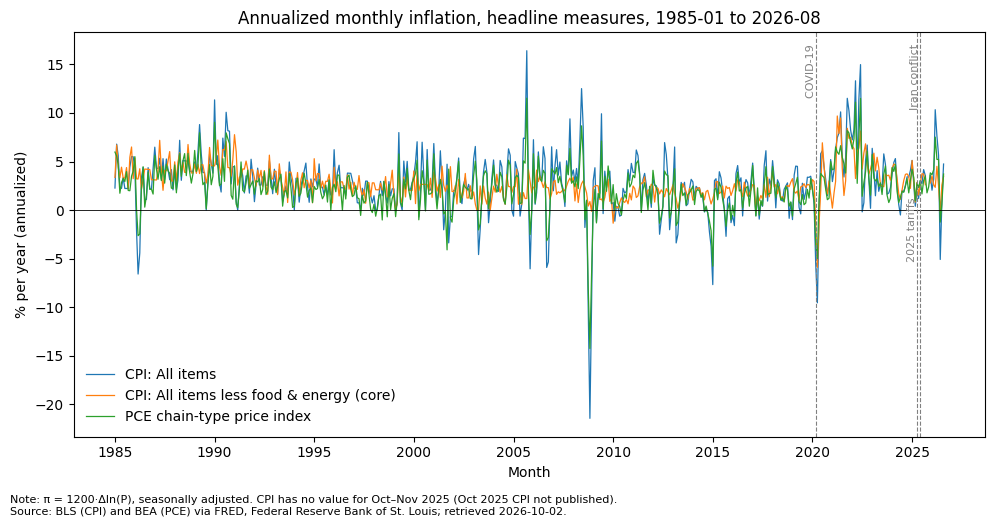

In [11]:
# Annualized monthly inflation (the transformed series used in estimation)
# for the three headline measures. Sub-categories are left out for now.
infl = tx["ann"][HEADLINE]

fig, ax = plt.subplots(figsize=(10, 5))
for k in infl:
    ax.plot(infl.index, infl[k], lw=0.9, label=LABELS[k])
ax.axhline(0, color="black", lw=0.6)
mark_events(ax)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.set(title=f"Annualized monthly inflation, headline measures, "
             f"{SAMPLE_START[:7]} to {SAMPLE_END[:7]}",
       xlabel="Month", ylabel="% per year (annualized)")
ax.legend(loc="lower left", frameon=False)
# Two-line note: a single line runs past the figure edge, and bbox_inches="tight"
# would then widen the saved PNG and push the plot off-center.
fig.text(0.01, -0.04,
         f"Note: π = 1200·Δln(P), seasonally adjusted. CPI has no value for Oct–Nov 2025 "
         f"(Oct 2025 CPI not published).\n"
         f"Source: BLS (CPI) and BEA (PCE) via FRED, Federal Reserve Bank of St. Louis; "
         f"retrieved {RETRIEVED}.",
         fontsize=8, ha="left")
fig.tight_layout()
save_fig(fig, "fig_headline_inflation.png")
plt.show()